# Анализ мультимодальных моделей / Multimodal Models Analysis

Ноутбук загружает обученные мультимодальные модели классификации эмоций речи и оценивает их
на тестовом наборе данных **Dusha + RESD** (`dusha_resd_test.lmdb`).

Для каждой late-fusion модели выводятся:
- Групповые столбчатые диаграммы — сравнение метрик **аудио / текст / fusion**
- Сводные метрики fusion (Accuracy, Balanced Accuracy, Precision/Recall/F1, MCC, ROC-AUC)
- Отчёт по классам (Precision / Recall / F1)
- Матрица ошибок (confusion matrix)

**Веса фьюзии (α) — опубликованные (из `late_fusion/results/`):**

| Модель | α (вес аудио) |
|--------|---------------|
| Late Fusion Baseline (SVM + TF-IDF LogReg) | 0.35 |
| Late Fusion (CNN-BiLSTM + RuBERT) | 0.50 |
| Late Fusion (HuBERT + RuBERT) | 0.50 |

**Эмоции (4 класса):** `angry` · `sad` · `neutral` · `positive`

> Используются сторонние предобученные модели; их источники и лицензии — [SOURCES.md](../../../SOURCES.md).


---
## Содержание

| # | Модель | Fusion |
|---|--------|--------|
| 1 | [Late Fusion Baseline (SVM + TF-IDF LogReg)](#1-late-fusion-baseline-svm--tf-idf-logreg) | soft-voting, α = 0.35 |
| 2 | [Late Fusion (CNN-BiLSTM + RuBERT)](#2-late-fusion-cnn-bilstm--rubert) | soft-voting, α = 0.50 |
| 3 | [Late Fusion (HuBERT + RuBERT)](#3-late-fusion-hubert--rubert) | soft-voting, α = 0.50 |
| 4 | [Early Fusion Baseline (CNN-BiLSTM + RuBERT)](#4-early-fusion-baseline-cnn-bilstm--rubert) | ранняя фьюзия энкодеров |


In [5]:
import sys
from pathlib import Path

def _find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'ruintona' / 'my_experiments').is_dir():
            return p
    return None

_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is not None and str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from ruintona.my_experiments.utils.config_utils import (
    PROJECT_ROOT, DATASET_PATH, TARGET_NAMES, EMO2LABEL,
)

import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

AGGREGATED_DIR = DATASET_PATH / 'processed_dataset_090' / 'aggregated_dataset'

# ──────────────────────────────────────────────────────
# ВЫБОР ТЕСТОВОГО НАБОРА ДАННЫХ
# ──────────────────────────────────────────────────────
TEST_LMDB = AGGREGATED_DIR / 'dusha_resd_test.lmdb'  # Dusha + RESD
CHECKPOINTS_DIR = PROJECT_ROOT / 'my_experiments' / 'checkpoints'
AUDIO_CKPT = CHECKPOINTS_DIR / 'audio'
TEXT_CKPT = CHECKPOINTS_DIR / 'text'
MULTIMODAL_CKPT = CHECKPOINTS_DIR / 'multimodal'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Test dataset: {TEST_LMDB}')
print(f'Exists: {TEST_LMDB.exists()}')
print(f'Device: {DEVICE}')


Test dataset: /home/natlis/PycharmProjects/dusha_new/ruintona/data_processing/dataset/processed_dataset_090/aggregated_dataset/dusha_resd_test.lmdb
Exists: True
Device: cpu


---
## Вспомогательные функции


In [6]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ruintona.my_experiments.utils.lmdb_utils import (
    get_lmdb_length,
    open_lmdb_readonly,
    parse_label_to_index,
    safe_pickle_loads,
)
from ruintona.my_experiments.utils.model_io import load_pytorch_model
from ruintona.my_experiments.utils.metrics import (
    print_eval_block,
    compute_classification_metrics,
)


def extract_text(payload):
    for key in ('speaker_text', 'text', 'transcript', 'utterance'):
        if key in payload:
            text = str(payload[key]).strip().lower()
            text = re.sub(r'\s+', ' ', text)
            if text:
                return text
    return ''


def _normalize_waveform(raw_waveform):
    arr = np.asarray(raw_waveform)
    if arr.ndim != 1:
        arr = arr.reshape(-1)
    if arr.dtype == np.int16:
        arr = arr.astype(np.float32) / 32768.0
    else:
        arr = arr.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=-1.0)
        peak = np.max(np.abs(arr)) if arr.size > 0 else 1.0
        if peak > 1.0:
            arr = arr / peak
    return np.clip(np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=-1.0), -1.0, 1.0)


def predict_audio_batch(model, arrays, device):
    """Батчевый инференс EmotionCNNBiLSTM, эквивалентный поэлементному.

    Прямой батч с паддингом по времени НЕ эквивалентен per-sample: maxpool +
    conv(3x3) подтекают через границу реального сигнала, когда короче примеры
    дополняются до максимума. Поэтому conv считается per-sample (дёшево), а
    дорогой LSTM — батчем с явным восстановлением исходного порядка.
    forward() же модели вообще некорректен для батча с разными длинами
    (pack_padded_sequence(enforce_sorted=False) + gather по исходным длинам
    после pad_packed_sequence, возвращающей строки в отсортированном порядке).
    """
    import torch.nn.utils.rnn as rnn_utils

    B = len(arrays)
    out_lens = []
    feats_list = []
    with torch.no_grad():
        for a in arrays:
            x = torch.from_numpy(a).unsqueeze(0).to(device)
            f = model.conv(x)
            f = f.mean(dim=2).permute(0, 2, 1).contiguous()
            n = max(1, int(a.shape[-1]) // 4)
            n = min(n, f.shape[1])
            out_lens.append(n)
            feats_list.append(f[0, :n])

        out_lens = torch.tensor(out_lens, dtype=torch.long)
        out_max = int(out_lens.max())
        feats = torch.zeros((B, out_max, feats_list[0].shape[-1]), dtype=feats_list[0].dtype)
        for i, f in enumerate(feats_list):
            feats[i, : f.shape[0]] = f
        order = torch.argsort(out_lens, descending=True)
        inv = torch.empty_like(order)
        inv[order] = torch.arange(B)
        packed = rnn_utils.pack_padded_sequence(
            feats[order], out_lens[order], batch_first=True, enforce_sorted=True
        )
        packed_out, _ = model.lstm(packed)
        lstm_out, _ = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        idx = (out_lens[order] - 1).view(-1, 1, 1).expand(-1, 1, lstm_out.size(-1))
        last_valid = lstm_out.gather(dim=1, index=idx).squeeze(1)[inv]
        logits = model.classifier(last_valid)
        return torch.softmax(logits, dim=1).cpu().numpy()


METRIC_ORDER = [
    'accuracy', 'balanced_accuracy',
    'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted',
    'mcc', 'roc_auc_ovr_macro',
]
METRIC_LABELS = {
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced Acc',
    'precision_macro': 'Precision (macro)',
    'recall_macro': 'Recall (macro)',
    'f1_macro': 'F1 (macro)',
    'f1_weighted': 'F1 (weighted)',
    'mcc': 'MCC',
    'roc_auc_ovr_macro': 'ROC-AUC (OvR)',
}


def evaluate_and_plot(title, y_true, probs_audio, probs_text, alpha):
    """Метрики аудио / текст / fusion + групповой bar chart и детальный отчёт по fusion."""
    y_pred_audio = np.argmax(probs_audio, axis=1)
    y_pred_text = np.argmax(probs_text, axis=1)
    fused_probs = alpha * probs_audio + (1.0 - alpha) * probs_text
    y_pred_fusion = np.argmax(fused_probs, axis=1)

    m_audio = compute_classification_metrics(y_true, y_pred_audio, probs_audio)
    m_text = compute_classification_metrics(y_true, y_pred_text, probs_text)
    m_fusion = compute_classification_metrics(y_true, y_pred_fusion, fused_probs)

    x = np.arange(len(METRIC_ORDER))
    width = 0.26
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.bar(x - width, [m_audio[k] for k in METRIC_ORDER], width,
           label='Audio', color='#4a86c8')
    ax.bar(x, [m_text[k] for k in METRIC_ORDER], width,
           label='Text', color='#f4a261')
    ax.bar(x + width, [m_fusion[k] for k in METRIC_ORDER], width,
           label=f'Fusion (α={alpha:.2f})', color='#2a9d8f')
    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_LABELS[k] for k in METRIC_ORDER], fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{title}\nАудио vs Текст vs Fusion (α={alpha:.2f})', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=1)
    plt.tight_layout()
    plt.show()

    print_eval_block(
        f'{title} (Fusion, α={alpha:.2f}) - Test Metrics',
        m_fusion, y_true, y_pred_fusion,
    )

    return {
        'title': title,
        'alpha': float(alpha),
        'audio': m_audio,
        'text': m_text,
        'fusion': m_fusion,
    }


---
## Статистическая значимость объединения модальностей

Для каждой late/early fusion модели проверяется, является ли превосходство **fusion** над каждой
унимодальной веткой (**audio** и **text**) статистически значимым на одном и том же тестовом наборе
(`dusha_resd_test.lmdb`, парные предсказания):

- **McNemar-тест** на парных предсказаниях (Dietterich, 1998) — H0: модели ошибаются одинаково часто
  (тест использует только дискордантные пары: `n01` — fusion прав / модальность нет, `n10` — наоборот);
- **Парный bootstrap** (B=1000) — распределение разницы метрики `fusion - модальность` на ресемплированных
  тестовых наборах: 95% доверительный интервал (перцентильный) и двусторонний p-value.

Метрики: **Accuracy**, **Balanced Accuracy**, **F1-macro**. Значимость: `*** p<0.001`, `** p<0.01`, `* p<0.05`, `n.s.` иначе.

In [7]:
from scipy import stats as scipy_stats
from sklearn.metrics import f1_score as sk_f1_score


def _sig_star(p, alpha=0.05):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < alpha:
        return '*'
    return 'n.s.'


def mcnemar_test(y_true, y_pred_a, y_pred_b, correction=True):
    """McNemar-тест на парных предсказаниях (с поправкой на непрерывность).

    n01 — A верно, B неверно; n10 — B верно, A неверно.
    H0: обе модели ошибаются одинаково часто (n01 == n10).
    """
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)
    assert len(y_true) == len(y_pred_a) == len(y_pred_b), 'Длины предсказаний не совпадают'
    n01 = int(np.sum((y_pred_a == y_true) & (y_pred_b != y_true)))
    n10 = int(np.sum((y_pred_a != y_true) & (y_pred_b == y_true)))
    n_disc = n01 + n10
    if n_disc == 0:
        return {'n01': n01, 'n10': n10, 'discordant': 0, 'chi2': 0.0, 'p_value': 1.0}
    if correction:
        chi2 = (abs(n01 - n10) - 1.0) ** 2 / n_disc
    else:
        chi2 = (n01 - n10) ** 2 / n_disc
    return {
        'n01': n01,
        'n10': n10,
        'discordant': n_disc,
        'chi2': float(chi2),
        'p_value': float(scipy_stats.chi2.sf(chi2, df=1)),
    }


def _bootstrap_metric_diffs(y_true, y_pred_a, y_pred_b, metric, n_boot=1000, seed=42):
    """Парный bootstrap: массив разниц метрики (A - B) на ресемплированных тестовых наборах."""
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)
    n = len(y_true)
    classes = np.arange(int(max(y_true.max(), y_pred_a.max(), y_pred_b.max())) + 1)

    correct_a = y_pred_a == y_true
    correct_b = y_pred_b == y_true
    true_oh = y_true[:, None] == classes[None, :]
    pred_a_oh = y_pred_a[:, None] == classes[None, :]
    pred_b_oh = y_pred_b[:, None] == classes[None, :]

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    mask = np.stack([np.bincount(r, minlength=n) for r in idx]).astype(np.float64)  # [B, n]

    n_c = true_oh.T @ mask.T                       # [C, B] — размеры классов в ресемплах
    tp_a = (correct_a[:, None] & true_oh).T @ mask.T
    tp_b = (correct_b[:, None] & true_oh).T @ mask.T
    pred_c_a = pred_a_oh.T @ mask.T
    pred_c_b = pred_b_oh.T @ mask.T

    def _scores(tp, pred_c):
        recall = tp / np.where(n_c == 0, 1.0, n_c)
        precision = tp / np.where(pred_c == 0, 1.0, pred_c)
        f1 = np.nan_to_num(
            2.0 * precision * recall / np.where(precision + recall == 0, 1.0, precision + recall)
        )
        return recall.mean(axis=0), f1.mean(axis=0)

    bal_a, f1_a = _scores(tp_a, pred_c_a)
    bal_b, f1_b = _scores(tp_b, pred_c_b)
    acc_a = mask @ correct_a.astype(np.float64) / n
    acc_b = mask @ correct_b.astype(np.float64) / n

    if metric == 'accuracy':
        return acc_a - acc_b
    if metric == 'balanced_accuracy':
        return bal_a - bal_b
    if metric == 'f1_macro':
        return f1_a - f1_b
    raise ValueError(f'Неизвестная метрика: {metric}')


def _bootstrap_summary(diff):
    """95% перцентильный CI и двусторонний p-value для разницы метрик."""
    ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
    p = 2.0 * min(float(np.mean(diff <= 0.0)), float(np.mean(diff >= 0.0)))
    return float(ci_low), float(ci_high), min(1.0, p)


def _full_metric(y_true, y_pred, metric):
    if metric == 'accuracy':
        return float(np.mean(y_pred == y_true))
    if metric == 'balanced_accuracy':
        return float(np.mean([np.mean(y_pred[y_true == c] == c) for c in np.unique(y_true)]))
    if metric == 'f1_macro':
        return float(sk_f1_score(y_true, y_pred, average='macro', zero_division=0))
    raise ValueError(f'Неизвестная метрика: {metric}')


def significance_report(title, y_true, probs_fusion, probs_audio, probs_text, n_boot=1000, seed=42):
    """McNemar + парный bootstrap для сравнения fusion vs audio и fusion vs text."""
    y_true = np.asarray(y_true)
    y_audio = np.argmax(np.asarray(probs_audio), axis=1)
    y_text = np.argmax(np.asarray(probs_text), axis=1)
    y_fusion = np.argmax(np.asarray(probs_fusion), axis=1)
    assert len(y_true) == len(y_audio) == len(y_text) == len(y_fusion), 'Длины предсказаний не совпадают'

    comparisons = [
        ('Fusion vs Audio', y_fusion, y_audio),
        ('Fusion vs Text', y_fusion, y_text),
    ]
    result = {'title': title, 'mcnemar': {}, 'bootstrap': {}}

    print('=' * 78)
    print(f'  Статистическая значимость объединения модальностей — {title}')
    print('=' * 78)

    # ── 1. McNemar-тест ──
    rows = []
    for label, y_f, y_m in comparisons:
        m = mcnemar_test(y_true, y_f, y_m)
        result['mcnemar'][label] = m
        rows.append({
            'Сравнение': label,
            'n01 (fusion прав / модальность нет)': m['n01'],
            'n10 (модальность прав / fusion нет)': m['n10'],
            'χ²': round(m['chi2'], 3),
            'p-value': f"{m['p_value']:.4g}",
            'Значимость': _sig_star(m['p_value']),
        })
    print('\nMcNemar-тест на парных предсказаниях (H0: ошибки моделей одинаково часты):')
    display(pd.DataFrame(rows))

    # ── 2. Парный bootstrap ──
    for label, y_f, y_m in comparisons:
        rows = []
        result['bootstrap'][label] = {}
        for metric in ('accuracy', 'balanced_accuracy', 'f1_macro'):
            v_f = _full_metric(y_true, y_f, metric)
            v_m = _full_metric(y_true, y_m, metric)
            diff = _bootstrap_metric_diffs(y_true, y_f, y_m, metric, n_boot=n_boot, seed=seed)
            ci_low, ci_high, p = _bootstrap_summary(diff)
            result['bootstrap'][label][metric] = {
                'fusion': v_f, 'modality': v_m, 'diff': v_f - v_m,
                'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p,
            }
            rows.append({
                'Метрика': metric,
                'Fusion': round(v_f, 4),
                'Модальность': round(v_m, 4),
                'Δ': round(v_f - v_m, 4),
                '95% CI': f'[{ci_low:.4f}, {ci_high:.4f}]',
                'p-value': f'{p:.4g}',
                'Значимость': _sig_star(p),
            })
        print(f'\nПарный bootstrap (B={n_boot}, метрики fusion − модальность):  {label}')
        display(pd.DataFrame(rows))

    return result


---
## 1. Late Fusion Baseline (SVM + TF-IDF LogReg)

**Тип:** soft-voting fusion двух sklearn-моделей  
**Аудио:** SVM на фиксированных векторах (mean/std по мел-фичам) — `svm_combine_balanced_train_model.pkl`  
**Текст:** TF-IDF + Logistic Regression — `TF-IDF_LogReg_combine_balanced_train_model.pkl`  
**Fusion:** `alpha * P_audio + (1 - alpha) * P_text`, **α = 0.35**  
(опубликованный вес из `late_fusion/results/late_fusion_baseline_results_20260504_154902.json`)


In [8]:
from ruintona.my_experiments.multimodal.late_fusion.Late_Fusion_Baseline_SVM_TF_IDF import (
    FusionLmdbDataset as BaselineFusionDataset,
    collect_model_probs as baseline_collect_probs,
    _load_pickle,
)

baseline_audio_model = _load_pickle(AUDIO_CKPT / 'svm_combine_balanced_train_model.pkl')
baseline_audio_scaler = _load_pickle(AUDIO_CKPT / 'svm_combine_balanced_train_scaler.pkl')
baseline_text_model = _load_pickle(TEXT_CKPT / 'TF-IDF_LogReg_combine_balanced_train_model.pkl')
baseline_text_vectorizer = _load_pickle(TEXT_CKPT / 'TF-IDF_LogReg_combine_balanced_train_vectorizer.pkl')
print('Audio (SVM):', type(baseline_audio_model).__name__)
print('Text (TF-IDF LogReg):', type(baseline_text_model).__name__)

baseline_ds = BaselineFusionDataset(TEST_LMDB)
baseline_indices = np.arange(len(baseline_ds))
y_base, p_base_audio, p_base_text = baseline_collect_probs(
    audio_model=baseline_audio_model,
    audio_scaler=baseline_audio_scaler,
    text_model=baseline_text_model,
    text_vectorizer=baseline_text_vectorizer,
    dataset=baseline_ds,
    item_indices=baseline_indices,
    batch_size=256,
    desc='Baseline inference (test)',
)
print(f'Processed {len(y_base)} samples')


Audio (SVM): SVC
Text (TF-IDF LogReg): LogisticRegression


Сканирование dusha_resd_test.lmdb: 100%|██████████| 6616/6616 [00:00<00:00, 6916.39sample/s]
                                                                             

Processed 6616 samples


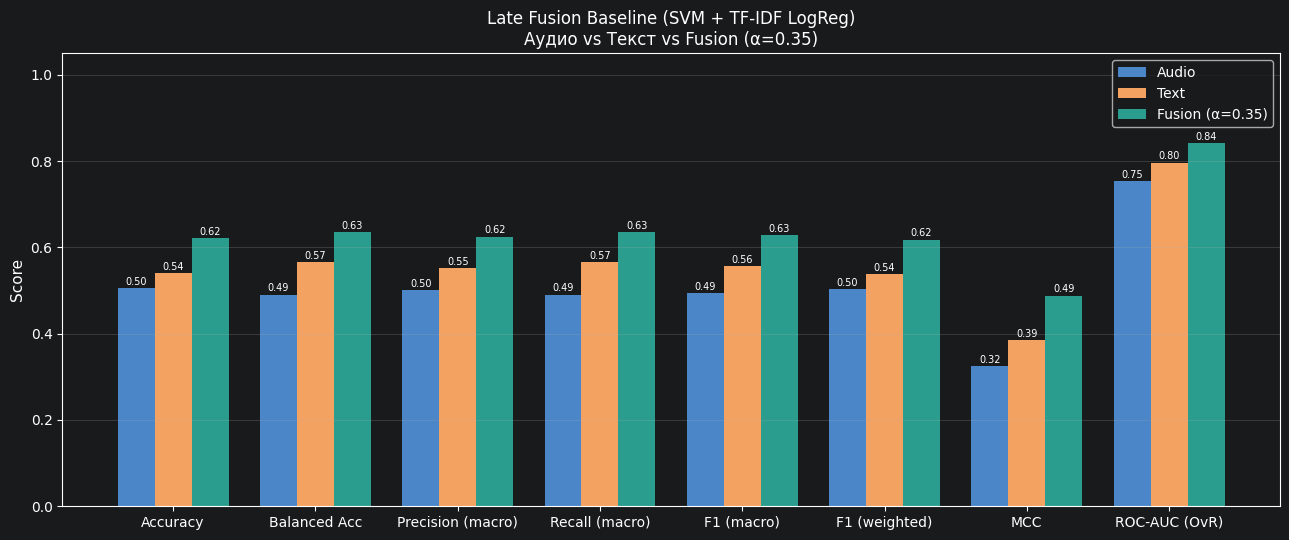


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Late Fusion Baseline (SVM + TF-IDF LogReg) (Fusion, α=0.35) - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.6211
1,Balanced Accuracy,0.6344
2,Precision (macro),0.6246
3,Recall (macro),0.6344
4,F1 (macro),0.6288
5,F1 (weighted),0.6177
6,MCC,0.4879
7,ROC-AUC (OvR macro),0.8408


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.6974,0.7678,0.7309,1378
1,sad,0.6299,0.6268,0.6283,2213
2,neutral,0.4623,0.4220,0.4412,1730
3,positive,0.7086,0.7212,0.7149,1295


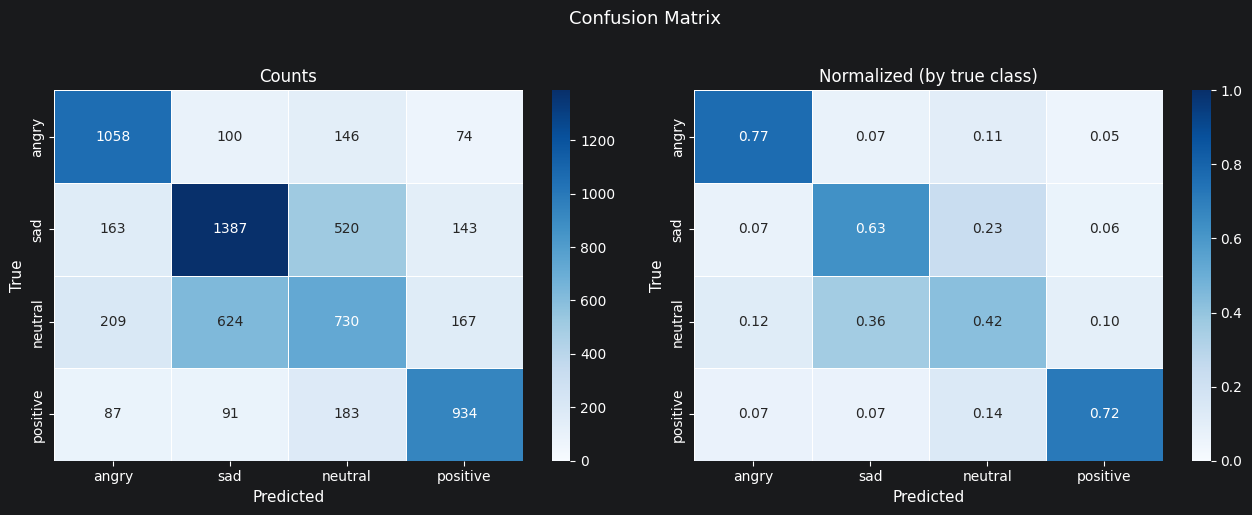

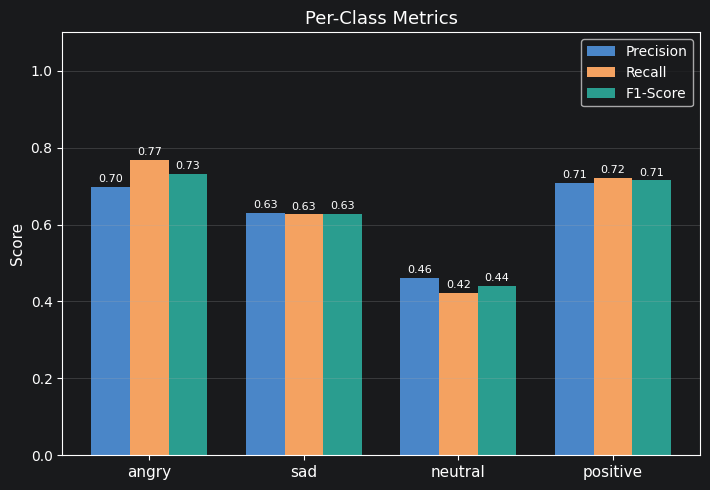

In [9]:
BASELINE_ALPHA = 0.35
baseline_summary = evaluate_and_plot(
    'Late Fusion Baseline (SVM + TF-IDF LogReg)',
    y_base, p_base_audio, p_base_text, alpha=BASELINE_ALPHA,
)


### Статистическая значимость fusion (Baseline)

In [10]:
fused_probs_base = BASELINE_ALPHA * p_base_audio + (1.0 - BASELINE_ALPHA) * p_base_text
baseline_sig = significance_report(
    'Late Fusion Baseline (SVM + TF-IDF LogReg)',
    y_base, fused_probs_base, p_base_audio, p_base_text,
)


  Статистическая значимость объединения модальностей — Late Fusion Baseline (SVM + TF-IDF LogReg)

McNemar-тест на парных предсказаниях (H0: ошибки моделей одинаково часты):


,Сравнение,n01 (fusion прав / модальность нет),n10 (модальность прав / fusion нет),χ²,p-value,Значимость
0,Fusion vs Audio,1259,491,336.165,4.366e-75,***
1,Fusion vs Text,1124,589,166.466,4.376e-38,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Audio


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.6211,0.5050,0.1161,"[0.1044, 0.1285]",0,***
1,balanced_accuracy,0.6344,0.4902,0.1442,"[0.1326, 0.1574]",0,***
2,f1_macro,0.6288,0.4942,0.1346,"[0.1229, 0.1476]",0,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Text


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.6211,0.5402,0.0809,"[0.0700, 0.0928]",0,***
1,balanced_accuracy,0.6344,0.5659,0.0685,"[0.0581, 0.0795]",0,***
2,f1_macro,0.6288,0.5561,0.0727,"[0.0622, 0.0838]",0,***


---
## 2. Late Fusion (CNN-BiLSTM + RuBERT)

**Тип:** soft-voting fusion двух предобученных PyTorch-моделей  
**Аудио:** `EmotionCNNBiLSTM` — `CNN_BiLSTM_combine_balanced_train_model.pt`  
**Текст:** `EmotionClassifier` (RuBERT) — `RuBERT_dusha_resd_train_model.pt`  
**Fusion:** `alpha * P_audio + (1 - alpha) * P_text`, **α = 0.50**  
(опубликованный вес из `late_fusion/results/Late_fusion_report`)


In [11]:
from transformers import AutoTokenizer
from ruintona.my_experiments.audio_models.CNN.CNN_BiLSTM import EmotionCNNBiLSTM
from ruintona.my_experiments.text_models.transformers.RuBERT import EmotionClassifier

# ── Загрузка аудио-модели ──
audio_ckpt_path = AUDIO_CKPT / 'CNN_BiLSTM_combine_balanced_train_model.pt'
audio_checkpoint = torch.load(audio_ckpt_path, map_location=DEVICE, weights_only=False)
if 'model_state_dict' in audio_checkpoint:
    audio_state = audio_checkpoint['model_state_dict']
else:
    audio_state = audio_checkpoint

audio_model = EmotionCNNBiLSTM(n_classes=4)
audio_model.load_state_dict(audio_state, strict=False)
audio_model.to(DEVICE)
audio_model.eval()
print(f'Audio model loaded from {audio_ckpt_path}')

# ── Загрузка текстовой модели ──
text_ckpt_path = TEXT_CKPT / 'RuBERT_dusha_resd_train_model.pt'
text_checkpoint = torch.load(text_ckpt_path, map_location=DEVICE, weights_only=False)
text_model_params = text_checkpoint.get('model_params', {})

text_model = EmotionClassifier(
    model_name=text_model_params.get('backbone_name', 'DeepPavlov/rubert-base-cased'),
    num_classes=4,
    dropout=text_model_params.get('dropout', 0.1),
    classifier_hidden_size=text_model_params.get('classifier_hidden_size', None),
)
text_model.load_state_dict(text_checkpoint['model_state_dict'], strict=False)
text_model.to(DEVICE)
text_model.eval()

tokenizer_dir = TEXT_CKPT / 'RuBERT_dusha_resd_train_tokenizer'
if tokenizer_dir.exists():
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)
else:
    tokenizer = AutoTokenizer.from_pretrained(
        text_model_params.get('backbone_name', 'DeepPavlov/rubert-base-cased')
    )
print(f'Text model loaded from {text_ckpt_path}')

max_len = int(text_model_params.get('max_len', 128))


Audio model loaded from /home/natlis/PycharmProjects/dusha_new/ruintona/my_experiments/checkpoints/audio/CNN_BiLSTM_combine_balanced_train_model.pt


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Text model loaded from /home/natlis/PycharmProjects/dusha_new/ruintona/my_experiments/checkpoints/text/RuBERT_dusha_resd_train_model.pt


In [12]:
env = open_lmdb_readonly(TEST_LMDB)
total = get_lmdb_length(env)

audio_arrays = []
texts = []
labels = []
with env.begin() as txn:
    for idx in range(total):
        raw = txn.get(str(idx).encode('utf-8'))
        if raw is None:
            continue
        payload = safe_pickle_loads(raw)
        if not isinstance(payload, dict):
            continue
        label_raw = payload.get('y', payload.get('label', payload.get('emotion')))
        try:
            label = parse_label_to_index(label_raw)
        except ValueError:
            continue
        text = extract_text(payload)
        if not text:
            continue
        if 'x' not in payload:
            continue
        arr = np.asarray(payload['x'], dtype=np.float32)
        if arr.ndim == 2:
            arr = arr[None, ...]
        audio_arrays.append(arr)
        texts.append(text)
        labels.append(label)
env.close()
y_cnn = np.array(labels)
print(f'Processed {len(y_cnn)} samples')

BATCH_SIZE = 32
probs_audio_cnn = np.zeros((len(y_cnn), 4), dtype=np.float32)
probs_text_cnn = np.zeros((len(y_cnn), 4), dtype=np.float32)

for start in range(0, len(y_cnn), BATCH_SIZE):
    end = start + BATCH_SIZE
    arrays = audio_arrays[start:end]
    probs_audio_cnn[start:end] = predict_audio_batch(audio_model, arrays, DEVICE)

    enc = tokenizer(
        texts[start:end], padding='max_length', truncation=True,
        max_length=max_len, return_tensors='pt',
    )
    with torch.no_grad():
        logits_t = text_model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        probs_text_cnn[start:end] = torch.softmax(logits_t, dim=1).cpu().numpy()

print('Done')


Processed 6616 samples
Done


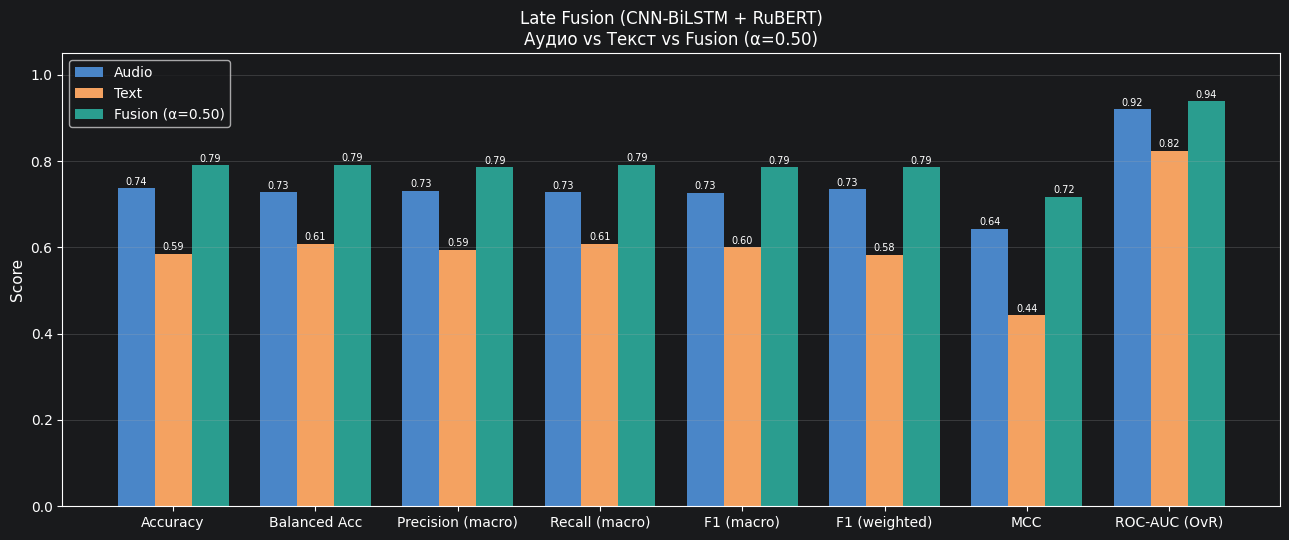


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Late Fusion (CNN-BiLSTM + RuBERT) (Fusion, α=0.50) - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.7901
1,Balanced Accuracy,0.7918
2,Precision (macro),0.7854
3,Recall (macro),0.7918
4,F1 (macro),0.7859
5,F1 (weighted),0.7864
6,MCC,0.7174
7,ROC-AUC (OvR macro),0.9380


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.7883,0.9107,0.8451,1378
1,sad,0.8208,0.8504,0.8353,2213
2,neutral,0.7469,0.6191,0.6770,1730
3,positive,0.7857,0.7869,0.7863,1295


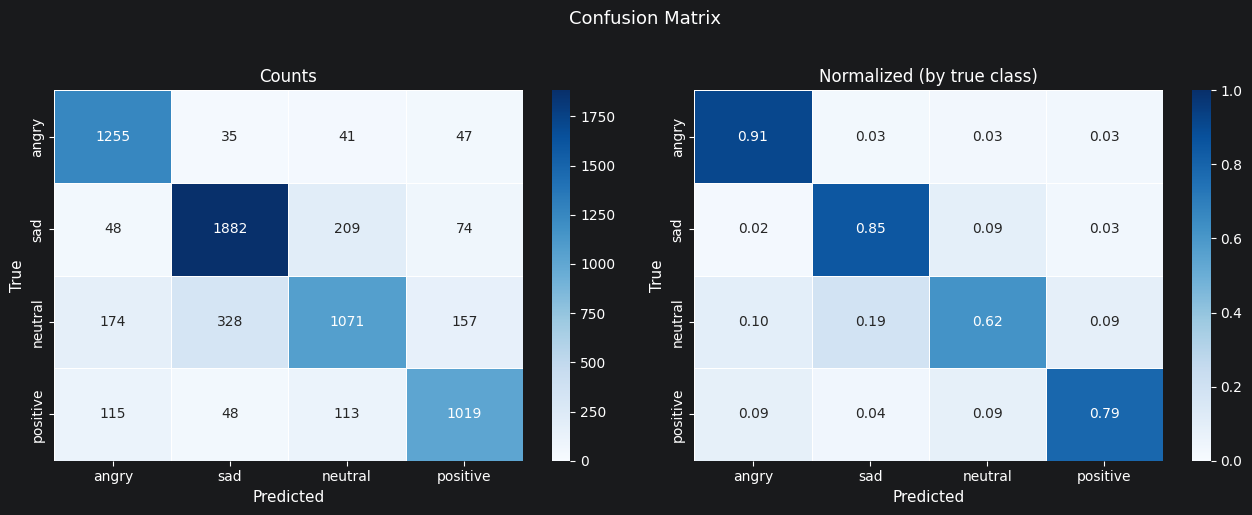

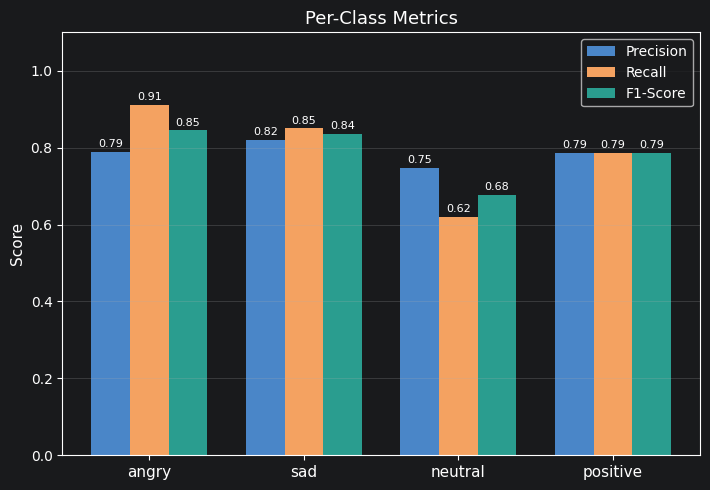

In [13]:
CNN_ALPHA = 0.50
cnn_summary = evaluate_and_plot(
    'Late Fusion (CNN-BiLSTM + RuBERT)',
    y_cnn, probs_audio_cnn, probs_text_cnn, alpha=CNN_ALPHA,
)


### Статистическая значимость fusion (CNN-BiLSTM + RuBERT)

In [14]:
fused_probs_cnn = CNN_ALPHA * probs_audio_cnn + (1.0 - CNN_ALPHA) * probs_text_cnn
cnn_sig = significance_report(
    'Late Fusion (CNN-BiLSTM + RuBERT)',
    y_cnn, fused_probs_cnn, probs_audio_cnn, probs_text_cnn,
)


  Статистическая значимость объединения модальностей — Late Fusion (CNN-BiLSTM + RuBERT)

McNemar-тест на парных предсказаниях (H0: ошибки моделей одинаково часты):


,Сравнение,n01 (fusion прав / модальность нет),n10 (модальность прав / fusion нет),χ²,p-value,Значимость
0,Fusion vs Audio,647,292,133.457,7.183e-31,***
1,Fusion vs Text,1695,342,897.351,3.696e-197,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Audio


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.7901,0.7364,0.0537,"[0.0444, 0.0624]",0,***
1,balanced_accuracy,0.7918,0.7272,0.0646,"[0.0550, 0.0742]",0,***
2,f1_macro,0.7859,0.7268,0.0591,"[0.0494, 0.0688]",0,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Text


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.7901,0.5856,0.2045,"[0.1927, 0.2170]",0,***
1,balanced_accuracy,0.7918,0.6087,0.1831,"[0.1717, 0.1946]",0,***
2,f1_macro,0.7859,0.6008,0.1851,"[0.1735, 0.1968]",0,***


---
## 3. Late Fusion (HuBERT + RuBERT)

**Тип:** soft-voting fusion двух предобученных PyTorch-моделей  
**Аудио:** HuBERT, дообученный на Dusha — `xbgoose/hubert-speech-emotion-recognition-russian-dusha-finetuned`  
(feature extractor `facebook/hubert-large-ls960-ft`, max_duration = 10 c)  
**Текст:** `EmotionClassifier` (RuBERT) — `RuBERT_dusha_resd_train_model.pt`  
**Fusion:** `alpha * P_audio + (1 - alpha) * P_text`, **α = 0.50**  
(опубликованный вес из `late_fusion/results/late_fusion_hubert_rubert_weights_20260525_210602.json`)


In [15]:
from torch.utils.data import DataLoader

from ruintona.my_experiments.multimodal.late_fusion.Late_Fusion_HuBERT_RuBERT import (
    FusionLmdbDataset as HuBERTFusionDataset,
    build_collate_fn as hubert_collate_fn,
    collect_model_probs as hubert_collect_probs,
    load_audio_model,
    load_text_model,
)

HUBERT_AUDIO_MODEL_ID = 'xbgoose/hubert-speech-emotion-recognition-russian-dusha-finetuned'
HUBERT_FEATURE_EXTRACTOR_ID = 'facebook/hubert-large-ls960-ft'
HUBERT_MAX_DURATION = 10.0
HUBERT_BATCH_SIZE = 8

hubert_audio_model, hubert_feature_extractor, hubert_label_to_index = load_audio_model(
    HUBERT_AUDIO_MODEL_ID,
    HUBERT_FEATURE_EXTRACTOR_ID,
    device=DEVICE,
)
hubert_text_model, hubert_tokenizer = load_text_model(
    TEXT_CKPT / 'RuBERT_dusha_resd_train_model.pt',
    tokenizer_dir=None,
    device=DEVICE,
)

hubert_ds = HuBERTFusionDataset(TEST_LMDB)
hubert_loader = DataLoader(
    hubert_ds,
    batch_size=HUBERT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=hubert_collate_fn(tokenizer=hubert_tokenizer, max_len=128),
)
print(f'Valid multimodal test samples: {len(hubert_ds)}')


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Сканирование dusha_resd_test.lmdb: 100%|██████████| 6616/6616 [00:11<00:00, 556.79sample/s]

Valid multimodal test samples: 6616


In [16]:
y_hubert, p_hubert_audio, p_hubert_text = hubert_collect_probs(
    audio_model=hubert_audio_model,
    feature_extractor=hubert_feature_extractor,
    audio_label_to_index=hubert_label_to_index,
    text_model=hubert_text_model,
    loader=hubert_loader,
    device=DEVICE,
    max_duration=HUBERT_MAX_DURATION,
    desc='HuBERT + RuBERT inference (test)',
)
print(f'Processed {len(y_hubert)} samples')


Processed 6616 samples


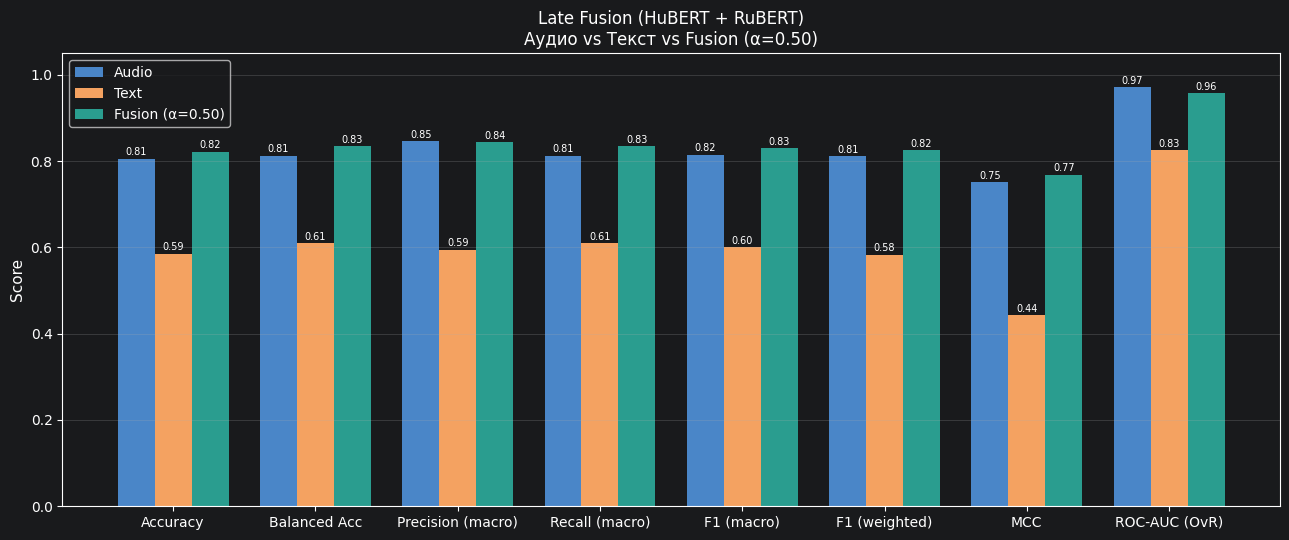


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Late Fusion (HuBERT + RuBERT) (Fusion, α=0.50) - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.8218
1,Balanced Accuracy,0.8339
2,Precision (macro),0.8432
3,Recall (macro),0.8339
4,F1 (macro),0.8301
5,F1 (weighted),0.8249
6,MCC,0.7681
7,ROC-AUC (OvR macro),0.9578


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.8746,0.8911,0.8828,1378
1,sad,0.9625,0.7198,0.8237,2213
2,neutral,0.6592,0.8798,0.7537,1730
3,positive,0.8766,0.8448,0.8604,1295


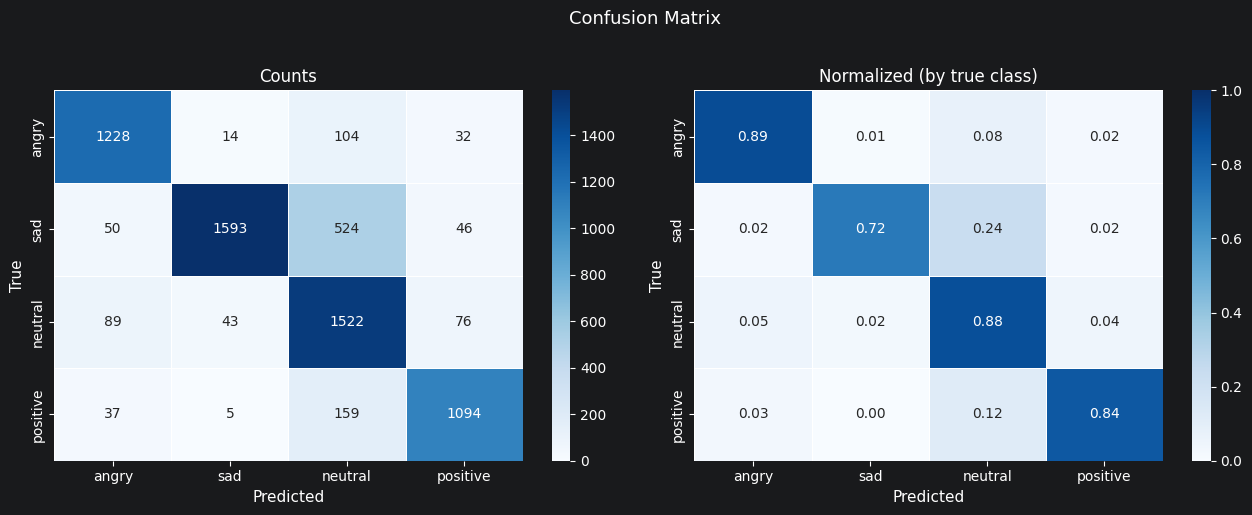

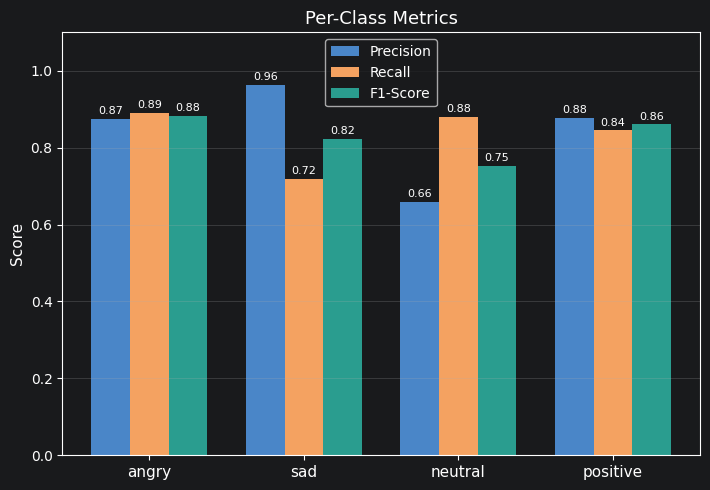

In [17]:
HUBERT_ALPHA = 0.50
hubert_summary = evaluate_and_plot(
    'Late Fusion (HuBERT + RuBERT)',
    y_hubert, p_hubert_audio, p_hubert_text, alpha=HUBERT_ALPHA,
)


### Статистическая значимость fusion (HuBERT + RuBERT)

In [18]:
fused_probs_hubert = HUBERT_ALPHA * p_hubert_audio + (1.0 - HUBERT_ALPHA) * p_hubert_text
hubert_sig = significance_report(
    'Late Fusion (HuBERT + RuBERT)',
    y_hubert, fused_probs_hubert, p_hubert_audio, p_hubert_text,
)


  Статистическая значимость объединения модальностей — Late Fusion (HuBERT + RuBERT)

McNemar-тест на парных предсказаниях (H0: ошибки моделей одинаково часты):


,Сравнение,n01 (fusion прав / модальность нет),n10 (модальность прав / fusion нет),χ²,p-value,Значимость
0,Fusion vs Audio,334,224,21.292,3.944e-06,***
1,Fusion vs Text,1891,329,1097.622,1.086e-240,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Audio


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.8218,0.8052,0.0166,"[0.0098, 0.0236]",0,***
1,balanced_accuracy,0.8339,0.8127,0.0211,"[0.0141, 0.0281]",0,***
2,f1_macro,0.8301,0.8150,0.0151,"[0.0081, 0.0218]",0,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Text


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.8218,0.5857,0.2361,"[0.2237, 0.2491]",0,***
1,balanced_accuracy,0.8339,0.6092,0.2246,"[0.2134, 0.2371]",0,***
2,f1_macro,0.8301,0.6007,0.2294,"[0.2184, 0.2421]",0,***


---
## 4. Early Fusion Baseline (CNN-BiLSTM + RuBERT)

**Тип:** ранняя фьюзия замороженных энкодеров + обучаемая голова (attention-pooling + проекции + MLP).

**Модель:** чекпоинт `Early_Fusion_Baseline_dusha_resd_train_model.pt` (класс `EarlyFusionModel`):
- аудио: CNN-BiLSTM (frozen, bidirectional LSTM hidden=128, layers=2)
- текст: RuBERT `DeepPavlov/rubert-base-cased` (frozen, CLS-вектор)
- голова: `AttentionPooling` + линейные проекции (projection_dim=256) + MLP на 4 класса

**Обучение:** `dusha_resd_train.lmdb` (best epoch 1, best val F1-macro 0.8793).

**Оценка:** `dusha_resd_test.lmdb`. Метрики пересчитаны **из сырых данных** — полный прогон замороженных
энкодеров + головы, независимо от кэша фич `early_fusion_features/`.


✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/ruintona/my_experiments/checkpoints/multimodal/Early_Fusion_Baseline_dusha_resd_train_model_20260806_165625.pt


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Сканирование dusha_resd_test.lmdb: 100%|██████████| 6616/6616 [00:00<00:00, 10526.52sample/s]


Валидных мультимодальных тестовых сэмплов: 6616
Processed 6616 samples

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Early Fusion Baseline (CNN-BiLSTM + RuBERT) - Test Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall Metrics:


,Metric,Value
0,Accuracy,0.7949
1,Balanced Accuracy,0.7977
2,Precision (macro),0.7931
3,Recall (macro),0.7977
4,F1 (macro),0.7952
5,F1 (weighted),0.7948
6,MCC,0.7228
7,ROC-AUC (OvR macro),0.9475


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.8409,0.8556,0.8482,1378
1,sad,0.8480,0.8220,0.8348,2213
2,neutral,0.6994,0.6925,0.6959,1730
3,positive,0.7839,0.8208,0.8020,1295


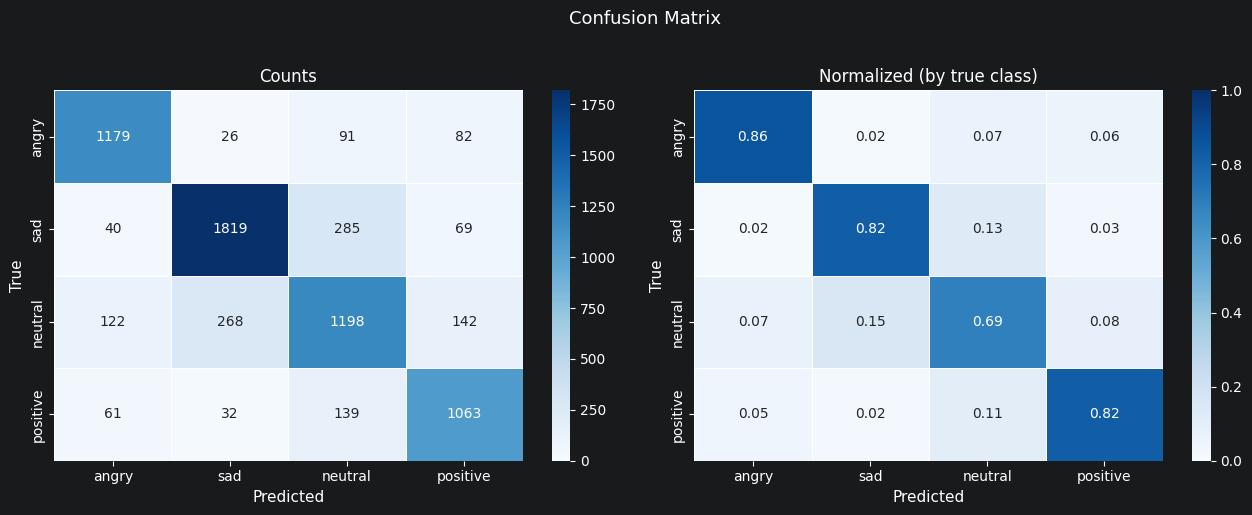

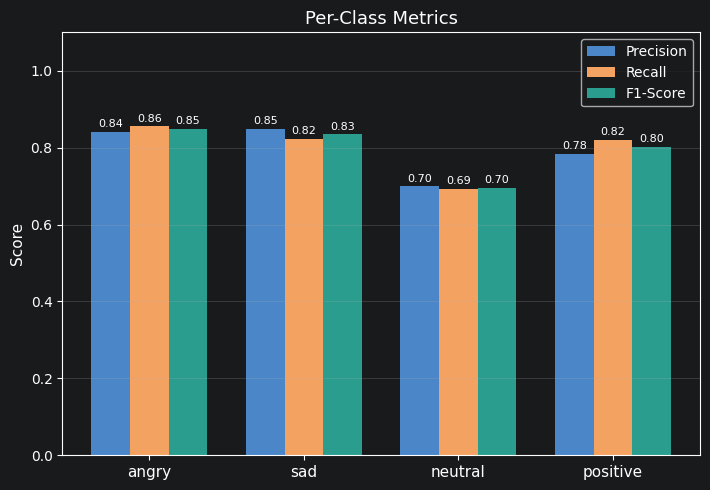

✓ Checkpoint загружен из /home/natlis/PycharmProjects/dusha_new/ruintona/my_experiments/checkpoints/multimodal/Early_Fusion_Baseline_dusha_resd_train_model_20260806_165625.pt
Метрики из чекпоинта (при обучении): {'loss': 0.559, 'accuracy': 0.7949, 'wa': 0.7949, 'balanced_accuracy': 0.7977, 'uar': 0.7977, 'precision_macro': 0.7931, 'recall_macro': 0.7977, 'f1_macro': 0.7952, 'f1_weighted': 0.7948}


In [19]:
from torch.utils.data import DataLoader

from ruintona.my_experiments.multimodal.early_fusion.Early_Fusion_Baseline import (
    FusionLmdbDataset,
    build_collate_fn,
    load_model,
)

# 1. Реконструкция модели из единого чекпоинта (model_params + state_dict)
model_ef, tokenizer_ef = load_model(
    'dusha_resd_train',
    model_name='Early_Fusion_Baseline',
    map_location=DEVICE,
)
model_ef.to(DEVICE)
model_ef.eval()

# max_len совпадает с обучением (training_params['max_len'] в чекпоинте = 128)
max_len_ef = 128

# 2. Сырой тестовый набор — пересчёт независимо от кэша фич
test_ds = FusionLmdbDataset(TEST_LMDB)
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=build_collate_fn(tokenizer=tokenizer_ef, max_len=max_len_ef),
)
print(f'Валидных мультимодальных тестовых сэмплов: {len(test_ds)}')

# 3. Инференс полной модели: frozen CNN-BiLSTM + frozen RuBERT + обучаемая голова
all_logits = []
all_labels = []
with torch.no_grad():
    for audio_x, lengths, input_ids, attention_mask, labels in test_loader:
        audio_x = audio_x.to(DEVICE)
        lengths = lengths.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        logits = model_ef(audio_x, lengths, input_ids, attention_mask)
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.numpy())

logits_ef = np.concatenate(all_logits)
probs_ef = torch.softmax(torch.from_numpy(logits_ef), dim=1).numpy()
y_true_ef = np.concatenate(all_labels)
y_pred_ef = np.argmax(probs_ef, axis=1)
print(f'Processed {len(y_true_ef)} samples')

# 4. Тестовые метрики
metrics_ef = compute_classification_metrics(y_true_ef, y_pred_ef, probs_ef)
print_eval_block(
    'Early Fusion Baseline (CNN-BiLSTM + RuBERT) - Test Metrics',
    metrics_ef,
    y_true_ef,
    y_pred_ef,
)

# 5. Сверка с метриками, сохранёнными при обучении
ckpt_ef = load_pytorch_model(
    'dusha_resd_train',
    models_dir=MULTIMODAL_CKPT,
    model_name='Early_Fusion_Baseline',
    map_location='cpu',
)
print('Метрики из чекпоинта (при обучении):', {
    k: round(v, 4) for k, v in (ckpt_ef.get('test_metrics') or {}).items()
})


### Сравнение унимодальных моделей и early fusion

Групповая столбчатая диаграмма сравнения метрик **аудио (CNN-BiLSTM)** и **текста (RuBERT)** с их **early fusion**
на тестовом наборе `dusha_resd_test.lmdb`. Унимодальные ветки — отдельно обученные модели из секции 2
(`probs_audio_cnn` / `probs_text_cnn`); фьюзия — выход обученной early-fusion модели (`probs_ef`).
Порядок и состав выборок выровнены (6616 сэмплов в идентичном порядке).

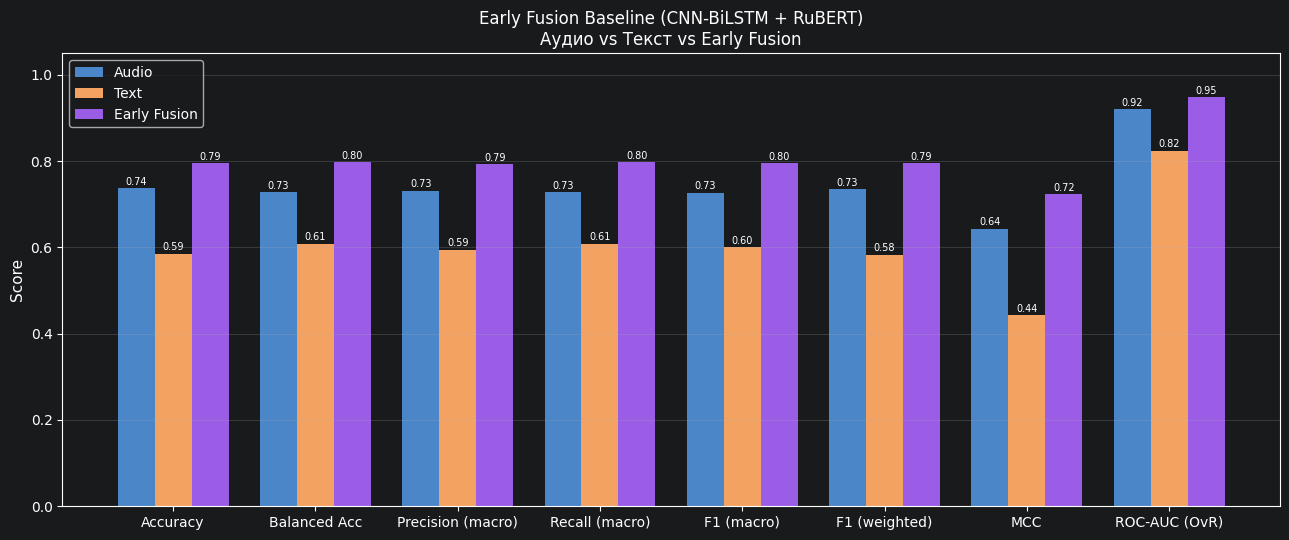

In [20]:
y_pred_audio_ef = np.argmax(probs_audio_cnn, axis=1)
y_pred_text_ef = np.argmax(probs_text_cnn, axis=1)
y_pred_ef_plot = np.argmax(probs_ef, axis=1)

m_audio_ef = compute_classification_metrics(y_true_ef, y_pred_audio_ef, probs_audio_cnn)
m_text_ef = compute_classification_metrics(y_true_ef, y_pred_text_ef, probs_text_cnn)
m_ef_plot = compute_classification_metrics(y_true_ef, y_pred_ef_plot, probs_ef)

x_ef = np.arange(len(METRIC_ORDER))
width_ef = 0.26
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x_ef - width_ef, [m_audio_ef[k] for k in METRIC_ORDER], width_ef,
       label='Audio', color='#4a86c8')
ax.bar(x_ef, [m_text_ef[k] for k in METRIC_ORDER], width_ef,
       label='Text', color='#f4a261')
ax.bar(x_ef + width_ef, [m_ef_plot[k] for k in METRIC_ORDER], width_ef,
       label='Early Fusion', color='#9b5de5')
ax.set_xticks(x_ef)
ax.set_xticklabels([METRIC_LABELS[k] for k in METRIC_ORDER], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Early Fusion Baseline (CNN-BiLSTM + RuBERT)\nАудио vs Текст vs Early Fusion', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=1)
plt.tight_layout()
plt.show()


### Статистическая значимость fusion (Early Fusion)

Сравнение с унимодальными ветками выполняется по предсказаниям **отдельно обученных** унимодальных
моделей из секции 2 (CNN-BiLSTM `probs_audio_cnn` и RuBERT `probs_text_cnn`). Порядок и состав
выборок выровнены с `dusha_resd_test.lmdb` (обе фильтрации дают 6616 сэмплов в идентичном порядке).

In [21]:
assert len(y_true_ef) == len(probs_audio_cnn) == len(probs_text_cnn), \
    'Длины предсказаний унимодальных моделей и early fusion не совпадают'
early_fusion_sig = significance_report(
    'Early Fusion Baseline (CNN-BiLSTM + RuBERT)',
    y_true_ef, probs_ef, probs_audio_cnn, probs_text_cnn,
)


  Статистическая значимость объединения модальностей — Early Fusion Baseline (CNN-BiLSTM + RuBERT)

McNemar-тест на парных предсказаниях (H0: ошибки моделей одинаково часты):


,Сравнение,n01 (fusion прав / модальность нет),n10 (модальность прав / fusion нет),χ²,p-value,Значимость
0,Fusion vs Audio,793,406,124.267,7.364e-29,***
1,Fusion vs Text,1740,355,914.299,7.646e-201,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Audio


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.7949,0.7364,0.0585,"[0.0493, 0.0685]",0,***
1,balanced_accuracy,0.7977,0.7272,0.0705,"[0.0608, 0.0816]",0,***
2,f1_macro,0.7952,0.7268,0.0684,"[0.0582, 0.0796]",0,***



Парный bootstrap (B=1000, метрики fusion − модальность):  Fusion vs Text


,Метрика,Fusion,Модальность,Δ,95% CI,p-value,Значимость
0,accuracy,0.7949,0.5856,0.2093,"[0.1966, 0.2223]",0,***
1,balanced_accuracy,0.7977,0.6087,0.1891,"[0.1779, 0.2007]",0,***
2,f1_macro,0.7952,0.6008,0.1944,"[0.1834, 0.2062]",0,***
